# 1. Importação de Bibliotecas e carregamento de dados

## 1.1. Bibliotecas

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import openpyxl

In [87]:
file_path = 'data/raw/BASE_PEDE_2024-DATATHON.xlsx'
xls = pd.ExcelFile(file_path)

# Listar as abas disponíveis
print(xls.sheet_names)

# Carregar cada aba em um DataFrame
df1 = pd.read_excel(xls, 'PEDE2022')
df2 = pd.read_excel(xls, 'PEDE2023')
df3 = pd.read_excel(xls, 'PEDE2024')

# Incluir coluna de ano em cada DataFrame
df1['Ano'] = 2022
df2['Ano'] = 2023
df3['Ano'] = 2024

['PEDE2022', 'PEDE2023', 'PEDE2024']


In [88]:
#verificar quantidade de linhas e colunas de cada DataFrame
print(df1.shape)
print(df2.shape)
print(df3.shape)

(860, 43)
(1014, 49)
(1156, 51)


In [89]:
# verificar dados distintos coluna Gênero
print(df1['Gênero'].unique())
print(df2['Gênero'].unique())
print(df3['Gênero'].unique())
    

<StringArray>
['Menina', 'Menino']
Length: 2, dtype: str
<StringArray>
['Feminino', 'Masculino']
Length: 2, dtype: str
<StringArray>
['Masculino', 'Feminino']
Length: 2, dtype: str


In [90]:
# Substituição/Padronização de gênero entre bases
df1['Gênero'] = df1['Gênero'].replace({'Menino': 'Masculino', 'Menina': 'Feminino'})
# Verificar os valores únicos após a padronização
print(df1['Gênero'].unique())

<StringArray>
['Feminino', 'Masculino']
Length: 2, dtype: str


In [91]:
#Padronização de labels das colunas
def padronizar_colunas(df):
    df.columns = df.columns.str.strip().str.upper()
    return df

df1 = padronizar_colunas(df1)
df2 = padronizar_colunas(df2)
df3 = padronizar_colunas(df3)

# mapeamento de labels
mapa_colunas = {
    'GÊNERO': 'GENERO'
}

df1 = df1.rename(columns=mapa_colunas)
df2 = df2.rename(columns=mapa_colunas)
df3 = df3.rename(columns=mapa_colunas)


1. Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

In [92]:
# Classificação do IAN
def classificar_ian(valor):
    if valor == 2.5:
        return 'Severa'
    elif valor == 5.0:
        return 'Moderada'
    elif valor == 10.0:
        return 'Adequado'
    else:
        return 'Outro'

df_pergunta1 = pd.concat([df1[['GENERO', 'IAN', 'ANO']], df2[['GENERO', 'IAN', 'ANO']], df3[['GENERO', 'IAN', 'ANO']]], ignore_index=True)
df_pergunta1['CATEGORIA_IAN'] = df_pergunta1['IAN'].apply(classificar_ian)


# Distribuição geral
contagem = df_pergunta1['CATEGORIA_IAN'].value_counts()
percentual = df_pergunta1['CATEGORIA_IAN'].value_counts(normalize=True) * 100

print("Distribuição geral:")
print(contagem)

print("\nPercentual geral:")
print(percentual)

# Distribuição por ANO
dist_ano = df_pergunta1.groupby(['ANO', 'CATEGORIA_IAN']).size().unstack(fill_value=0)
print("\nDistribuição por ano (absoluto):")
print(dist_ano)

# Percentual por ano
dist_ano_pct = dist_ano.div(dist_ano.sum(axis=1), axis=0) * 100
print("\nDistribuição por ano (%):")
print(dist_ano_pct)

# Evolução do IAN
media_ano = df_pergunta1.groupby('ANO')['IAN'].mean().reset_index()
print("\nMédia de IAN por ano:")
print(media_ano)


media_genero = df_pergunta1.groupby(['ANO', 'GENERO'])['IAN'].mean().reset_index()
print("\nMédia por ano e gênero:")
print(media_genero)


Distribuição geral:
CATEGORIA_IAN
Moderada    1642
Adequado    1343
Severa        45
Name: count, dtype: int64

Percentual geral:
CATEGORIA_IAN
Moderada    54.191419
Adequado    44.323432
Severa       1.485149
Name: proportion, dtype: float64

Distribuição por ano (absoluto):
CATEGORIA_IAN  Adequado  Moderada  Severa
ANO                                      
2022                259       573      28
2023                462       538      14
2024                622       531       3

Distribuição por ano (%):
CATEGORIA_IAN   Adequado   Moderada    Severa
ANO                                          
2022           30.116279  66.627907  3.255814
2023           45.562130  53.057199  1.380671
2024           53.806228  45.934256  0.259516

Média de IAN por ano:
    ANO       IAN
0  2022  6.424419
1  2023  7.243590
2  2024  7.683824

Média por ano e gênero:
    ANO     GENERO       IAN
0  2022   Feminino  6.477024
1  2022  Masculino  6.364764
2  2023   Feminino  7.477106
3  2023  Masculino  

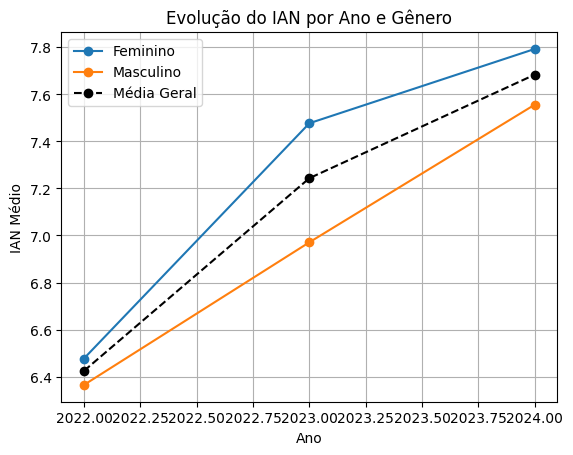

In [93]:
# Gráfico Evolução

plt.figure()

for genero in media_genero['GENERO'].dropna().unique():
    subset = media_genero[media_genero['GENERO'] == genero]
    plt.plot(subset['ANO'], subset['IAN'], marker='o', label=str(genero))
plt.plot(media_ano['ANO'], media_ano['IAN'], marker='o', label='Média Geral', linestyle='--', color='black')
plt.title('Evolução do IAN por Ano e Gênero')
plt.xlabel('Ano')
plt.ylabel('IAN Médio')
plt.legend()
plt.grid(True)
plt.show()